In [37]:
import os
from pathlib import Path
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import re

QF_DISPLAY = {
    "body": "Original Query",
    "synonyms": "+ Gene Synonyms",
    "long": "+ Gene Synonyms & Products",
}

RERANK_DISPLAY = {
    "body": "Rerank (Original Query)",
    "synonyms": "Rerank (+ Gene Synonyms)",
    "long": "Rerank (+ Gene Synonyms & Products)",
    "hybrid": "Retrieval Fusion",
}

## Query-field sweep: statistical comparison (recall 200–1000)

We compare retrieval profiles (e.g. hybrid combo bm25_qf × dense_qf) using **mean recall over K ∈ {200, 300, 400, 500, 1000}** so the choice of operating point (e.g. rerank cutoff) does not dominate. Data from `scripts/public/combine_query_field_sweep_results.py` (combined sweep metrics). Stats: mean ± std across batches (train/test), rank, and optional paired test of best vs others.

In [38]:
# Prefer combined_sweep_metrics (long), then combined_sweep_metrics_wide, then legacy workflow_hpc_test.
root = Path(os.environ.get("DICTYCITE_ROOT", "../"))
_candidates = [
    root / "output/workflow_baseline_full_sweep/query_field_sweep/combined_sweep_metrics.csv",
    root / "output/workflow_baseline_full_sweep/query_field_sweep/combined_sweep_metrics_wide.csv",
    root / "output/workflow_hpc_test/combined_sweep_metrics.csv",
    Path("../output/workflow_baseline_full_sweep/query_field_sweep/combined_sweep_metrics.csv"),
    Path("../output/workflow_baseline_full_sweep/query_field_sweep/combined_sweep_metrics_wide.csv"),
    Path("../output/workflow_hpc_test/combined_sweep_metrics.csv"),
]
SWEEP_CSV = None
for _p in _candidates:
    if _p.is_file():
        SWEEP_CSV = _p
        break

if SWEEP_CSV is None:
    sweep_dir = root / "output/workflow_baseline_full_sweep/query_field_sweep"
    if not sweep_dir.is_dir():
        sweep_dir = Path("../output/workflow_baseline_full_sweep/query_field_sweep")
    if sweep_dir.is_dir():
        raise FileNotFoundError(
            f"No combined_sweep_metrics*.csv found under {sweep_dir}. "
            "Run scripts/private_scripts/hpc_scripts/query_expansion/combine_query_field_sweep_results.py "
            "with --workflow_dir pointing to this directory."
        )
    else:
        raise FileNotFoundError("Query-field sweep directory not found; check DICTYCITE_ROOT and output paths.")

In [39]:
# Path to combined sweep metrics (from combine_query_field_sweep_results.py)

K_RANGE = [200, 300, 400, 500, 1000]  # recall@K range for "operating region" metric
MEANR_COLS = [f"MeanR@{k}" for k in K_RANGE]

df = pd.read_csv(SWEEP_CSV)

# If we loaded the wide-format combined_sweep_metrics_wide.csv, reshape to long format
# expected by the rest of this notebook (stage + bm25_query_field + dense_query_field + MeanR@K).
if SWEEP_CSV.name.endswith("combined_sweep_metrics_wide.csv"):
    if "query_field" not in df.columns:
        raise ValueError(f"Expected 'query_field' column in wide sweep metrics, got: {list(df.columns)}")

    rows_long = []
    methods = ["bm25", "dense", "hybrid"]
    roles = ["train", "test"]
    for _, row in df.iterrows():
        qf = str(row["query_field"]).strip()
        for method in methods:
            for role in roles:
                rec_vals = {}
                for k in K_RANGE:
                    wide_col = f"{role}_{method}_MeanR@{k}"
                    if wide_col in df.columns:
                        rec_vals[f"MeanR@{k}"] = float(row[wide_col])
                if not rec_vals:
                    continue
                rows_long.append({
                    "stage": method,
                    "bm25_query_field": qf,
                    "dense_query_field": qf,
                    "batch": role,
                    **rec_vals,
                })
    if not rows_long:
        raise ValueError("No MeanR@K columns found in wide sweep metrics; cannot build long-format table.")
    df = pd.DataFrame(rows_long)

# Ensure we have the recall columns (hybrid/bm25/dense may have different column sets)
available = [c for c in MEANR_COLS if c in df.columns]
if not available:
    raise ValueError(f"None of {MEANR_COLS} found in {SWEEP_CSV}. Columns: {list(df.columns)}")

# Mean recall over K in [200, 500, 1000] per (profile, batch). Profile = stage + query fields.
df["batch"] = df["batch"].astype(str).str.strip()
if "stage" in df.columns:
    df["stage"] = df["stage"].astype(str).str.strip()
if "bm25_query_field" in df.columns and "dense_query_field" in df.columns:
    df["bm25_query_field"] = df["bm25_query_field"].astype(str).str.strip()
    df["dense_query_field"] = df["dense_query_field"].astype(str).str.strip()
    df["bm25_qf_display"] = df["bm25_query_field"].map(QF_DISPLAY).fillna(df["bm25_query_field"])
    df["dense_qf_display"] = df["dense_query_field"].map(QF_DISPLAY).fillna(df["dense_query_field"])
    df["profile"] = df["stage"].str.upper() + " (" + df["bm25_qf_display"] + ", " + df["dense_qf_display"] + ")"
else:
    df["profile"] = df.get("stage", df.get("method", "unknown"))

# Operating-region mean recall across K
df["mean_recall_200_1000"] = df[available].mean(axis=1)

# Simple scoring profile: MeanR@500 + MeanR@1000 (when available)
score_cols = [c for c in ["MeanR@500", "MeanR@1000"] if c in df.columns]
if score_cols:
    df["score_r500_r1000"] = df[score_cols].sum(axis=1)

# Per-profile summary: mean/std across batches
agg_dict = {
    "mean_recall_200_1000": ["mean", "std"],
    "batch": ["nunique"],
}
if "score_r500_r1000" in df.columns:
    agg_dict["score_r500_r1000"] = ["mean"]

summary = df.groupby("profile").agg(agg_dict)
summary.columns = [
    "mean_recall" if c == ("mean_recall_200_1000", "mean") else
    "std_recall" if c == ("mean_recall_200_1000", "std") else
    "n_batches" if c == ("batch", "nunique") else
    "score_r500_r1000" if c == ("score_r500_r1000", "mean") else "_".join(map(str, c))
    for c in summary.columns
]
summary = summary.reset_index()

# Rank by score profile when available, otherwise by mean_recall
if "score_r500_r1000" in summary.columns:
    summary = summary.sort_values("score_r500_r1000", ascending=False).reset_index(drop=True)
else:
    summary = summary.sort_values("mean_recall", ascending=False).reset_index(drop=True)
summary["rank"] = range(1, len(summary) + 1)

print("Recall (mean over K in {200..1000}), mean ± std across batches:\n")
display(pl.from_pandas(summary))

# Per-stage top profiles for quick inspection (BM25 and Dense)
print("\nTop profiles by stage (ranked by score_r500_r1000 when available, else mean_recall):\n")

for stage in ["bm25", "dense"]:
    # Filter profiles belonging to this stage (profile starts with STAGE in upper-case)
    stage_profiles = summary[summary["profile"].str.upper().str.startswith(stage.upper())]
    if stage_profiles.empty:
        continue
    print(f"\n{stage.upper()} profiles:\n")
    display(pl.from_pandas(stage_profiles.head(5)))

Recall (mean over K in {200..1000}), mean ± std across batches:



profile,mean_recall,std_recall,n_batches,score_r500_r1000,rank
str,f64,f64,i64,f64,i64
"""BM25 (+ Gene Synonyms & Produc…",0.938131,0.022442,2,1.90256,1
"""BM25 (+ Gene Synonyms & Produc…",0.938131,0.022442,2,1.90256,2
"""BM25 (+ Gene Synonyms & Produc…",0.938131,0.022442,2,1.90256,3
"""BM25 (+ Gene Synonyms, + Gene …",0.929226,0.029379,2,1.888869,4
"""BM25 (+ Gene Synonyms, + Gene …",0.929226,0.029379,2,1.888869,5
…,…,…,…,…,…
"""DENSE (+ Gene Synonyms, + Gene…",0.901071,0.005286,2,1.865417,14
"""DENSE (Original Query, + Gene …",0.901071,0.005286,2,1.865417,15
"""DENSE (+ Gene Synonyms & Produ…",0.876988,0.013654,2,1.809583,16



Top profiles by stage (ranked by score_r500_r1000 when available, else mean_recall):


BM25 profiles:



profile,mean_recall,std_recall,n_batches,score_r500_r1000,rank
str,f64,f64,i64,f64,i64
"""BM25 (+ Gene Synonyms & Produc…",0.938131,0.022442,2,1.90256,1
"""BM25 (+ Gene Synonyms & Produc…",0.938131,0.022442,2,1.90256,2
"""BM25 (+ Gene Synonyms & Produc…",0.938131,0.022442,2,1.90256,3
"""BM25 (+ Gene Synonyms, + Gene …",0.929226,0.029379,2,1.888869,4
"""BM25 (+ Gene Synonyms, + Gene …",0.929226,0.029379,2,1.888869,5



DENSE profiles:



profile,mean_recall,std_recall,n_batches,score_r500_r1000,rank
str,f64,f64,i64,f64,i64
"""DENSE (Original Query, + Gene …",0.918024,0.001852,2,1.87494,7
"""DENSE (+ Gene Synonyms, + Gene…",0.918024,0.001852,2,1.87494,8
"""DENSE (+ Gene Synonyms & Produ…",0.918024,0.001852,2,1.87494,9
"""DENSE (+ Gene Synonyms & Produ…",0.901071,0.005286,2,1.865417,13
"""DENSE (+ Gene Synonyms, + Gene…",0.901071,0.005286,2,1.865417,14


In [40]:
# Compact per-stage summary: for each batch (train/test), three scores per query-field
# Uses score profile: MeanR@500 + MeanR@1000 when available.

batches = sorted(df["batch"].astype(str).str.strip().unique().tolist())

print("Per-stage summary by batch (BM25 and DENSE):\n")

for stage in ["bm25", "dense"]:
    stage_df = df[df["stage"] == stage].copy()
    if stage_df.empty:
        continue

    # Stage-specific query field
    if stage == "bm25":
        stage_df["qf"] = stage_df["bm25_query_field"].astype(str).str.strip()
    else:
        stage_df["qf"] = stage_df["dense_query_field"].astype(str).str.strip()
    stage_df["qf_display"] = stage_df["qf"].map(QF_DISPLAY).fillna(stage_df["qf"])

    # Score profile: MeanR@500 + MeanR@1000 (when available)
    score_cols = [c for c in ["MeanR@500", "MeanR@1000"] if c in stage_df.columns]
    if score_cols:
        stage_df["score_r500_r1000"] = stage_df[score_cols].sum(axis=1)

    stage_df["batch"] = stage_df["batch"].astype(str).str.strip()

    for batch in batches:
        sub = stage_df[stage_df["batch"] == batch]
        if sub.empty:
            continue

        agg = {
            "mean_recall_200_1000": "mean",
        }
        if "score_r500_r1000" in sub.columns:
            agg["score_r500_r1000"] = "mean"

        summary_stage = (
            sub.groupby("qf_display").agg(agg).reset_index()
        )

        # Rename columns for display
        cols = {"qf_display": "query_field", "mean_recall_200_1000": "mean_recall"}
        summary_stage = summary_stage.rename(columns=cols)

        # Sort by score if present, otherwise by mean_recall
        if "score_r500_r1000" in summary_stage.columns:
            summary_stage = summary_stage.sort_values("score_r500_r1000", ascending=False)
        else:
            summary_stage = summary_stage.sort_values("mean_recall", ascending=False)

        print(f"\n{stage.upper()} – {batch}:")
        display(pl.from_pandas(summary_stage))

Per-stage summary by batch (BM25 and DENSE):


BM25 – dicty_gold_llm_public_test_50:


query_field,mean_recall,score_r500_r1000
str,f64,f64
"""+ Gene Synonyms""",0.95,1.94
"""+ Gene Synonyms & Products""",0.954,1.94
"""Original Query""",0.928,1.91



BM25 – dicty_gold_llm_public_train_200:


query_field,mean_recall,score_r500_r1000
str,f64,f64
"""+ Gene Synonyms & Products""",0.922262,1.865119
"""+ Gene Synonyms""",0.908452,1.837738
"""Original Query""",0.898619,1.828571



DENSE – dicty_gold_llm_public_test_50:


query_field,mean_recall,score_r500_r1000
str,f64,f64
"""+ Gene Synonyms & Products""",0.919333,1.886667
"""+ Gene Synonyms""",0.897333,1.876667
"""Original Query""",0.867333,1.796667



DENSE – dicty_gold_llm_public_train_200:


query_field,mean_recall,score_r500_r1000
str,f64,f64
"""+ Gene Synonyms & Products""",0.916714,1.863214
"""+ Gene Synonyms""",0.90481,1.854167
"""Original Query""",0.886643,1.8225


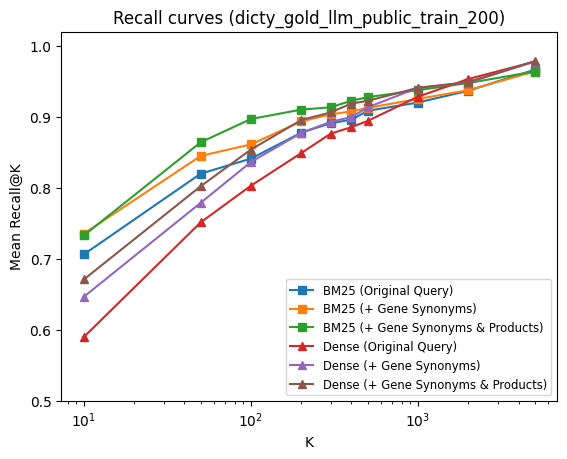

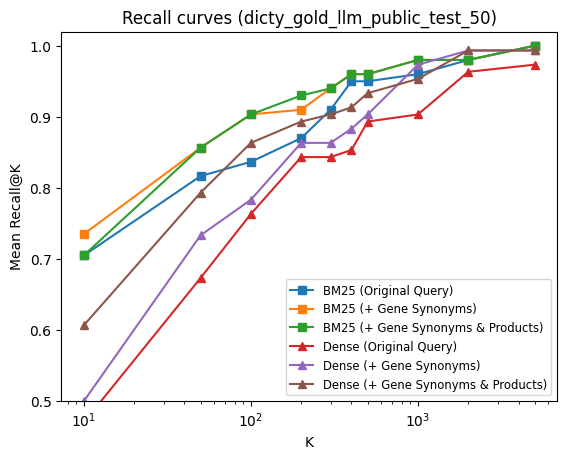

Saved recall curves with display labels to ../output/workflow_baseline_full_sweep/query_field_sweep/figures


In [33]:
# Plot recall curves per batch with display-name labels (BM25, Dense, Hybrid)
recall_cols = [c for c in df.columns if c.startswith("MeanR@")]
if not recall_cols:
    raise ValueError(f"No MeanR@K columns found in sweep metrics: {list(df.columns)}")
ks = [int(c.split("@")[1]) for c in recall_cols]

plot_df = df.copy()
plot_df["batch"] = plot_df["batch"].astype(str).str.strip()
plot_df["stage"] = plot_df["stage"].astype(str).str.strip()
plot_df["combo"] = plot_df.get("combo", "").astype(str).str.strip()
plot_df["bm25_qf"] = plot_df["bm25_query_field"].astype(str).str.strip()
plot_df["dense_qf"] = plot_df["dense_query_field"].astype(str).str.strip()

# Map internal query-field codes to display names
plot_df["bm25_qf_disp"] = plot_df["bm25_qf"].map(QF_DISPLAY).fillna(plot_df["bm25_qf"])
plot_df["dense_qf_disp"] = plot_df["dense_qf"].map(QF_DISPLAY).fillna(plot_df["dense_qf"])

batches = plot_df["batch"].unique().tolist()
qf_order = ["body", "synonyms", "long"]

figures_dir = Path("../output/workflow_baseline_full_sweep/query_field_sweep/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

for batch in batches:
    fig, ax = plt.subplots()
    subset = plot_df[plot_df["batch"] == batch]
    if subset.empty:
        continue

    # BM25: one curve per bm25_qf
    for qf in qf_order:
        rows = subset[(subset["stage"] == "bm25") & (subset["bm25_qf"] == qf)]
        if rows.empty:
            continue
        row = rows.iloc[0]
        vals = [float(row[c]) for c in recall_cols]
        label = f"BM25 ({QF_DISPLAY.get(qf, qf)})"
        ax.plot(ks, vals, marker="s", label=label)

    # Dense: one curve per dense_qf
    for qf in qf_order:
        rows = subset[(subset["stage"] == "dense") & (subset["dense_qf"] == qf)]
        if rows.empty:
            continue
        row = rows.iloc[0]
        vals = [float(row[c]) for c in recall_cols]
        label = f"Dense ({QF_DISPLAY.get(qf, qf)})"
        ax.plot(ks, vals, marker="^", label=label)

    # Hybrid: one curve per (bm25_qf, dense_qf)
    for bm25_qf in qf_order:
        for dense_qf in qf_order:
            rows = subset[
                (subset["stage"] == "hybrid")
                & (subset["bm25_qf"] == bm25_qf)
                & (subset["dense_qf"] == dense_qf)
            ]
            if rows.empty:
                continue
            row = rows.iloc[0]
            vals = [float(row[c]) for c in recall_cols]
            label = f"Hybrid ({QF_DISPLAY.get(bm25_qf, bm25_qf)}, {QF_DISPLAY.get(dense_qf, dense_qf)})"
            ax.plot(ks, vals, marker="o", label=label)

    ax.set_xlabel("K")
    ax.set_ylabel("Mean Recall@K")
    ax.set_title(f"Recall curves ({batch})")
    # Zoom y-axis to make curves more separated
    ax.set_ylim(0.5, 1.02)
    # Use log scale for K to spread points on x-axis
    ax.set_xscale("log")
    ax.legend(fontsize="small")

    safe_name = re.sub(r"[^\w\-]", "_", str(batch))
    out_path = figures_dir / f"recall_curve_displaynames_{safe_name}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"Saved recall curves with display labels to {figures_dir}")

## Rerank comparison: MAP@10 by query field (body vs synonyms vs long)

After reranking, we compare **MAP@10** across methods (body, synonyms, long, hybrid) using the output of `scripts/public/shared_scripts/compare_result_dirs.py` (compare_summary.csv). Stats: mean ± std across train/test splits, rank, and paired t-test of best vs others. This complements the retrieval recall comparison above: expansion helps recall at retrieval but does not improve MAP after reranking.

MAP@K summary (train and test):


TRAIN:


method,MAP@1,MAP@5,MAP@10,MAP@20,MAP@50,MAP@100,MAP@200
str,f64,f64,f64,f64,f64,f64,f64
"""Rerank (+ Gene Synonyms)""",0.585,0.5904,0.6029,0.6084,0.6115,0.6116,0.6119
"""Rerank (Original Query)""",0.575,0.5765,0.5883,0.5944,0.5967,0.5974,0.5976
"""Rerank (+ Gene Synonyms & Prod…",0.53,0.5637,0.5744,0.5793,0.5822,0.5828,0.5831
"""Retrieval Fusion""",0.505,0.5458,0.5573,0.5631,0.5663,0.5672,0.5674



TEST:


method,MAP@1,MAP@5,MAP@10,MAP@20,MAP@50,MAP@100,MAP@200
str,f64,f64,f64,f64,f64,f64,f64
"""Rerank (+ Gene Synonyms & Prod…",0.46,0.5483,0.5599,0.5712,0.5732,0.5732,0.5736
"""Rerank (+ Gene Synonyms)""",0.48,0.5337,0.5522,0.5634,0.5663,0.5665,0.5668
"""Rerank (Original Query)""",0.44,0.5212,0.5352,0.5453,0.5459,0.5472,0.5475
"""Retrieval Fusion""",0.44,0.4887,0.5047,0.5065,0.5116,0.5127,0.5129


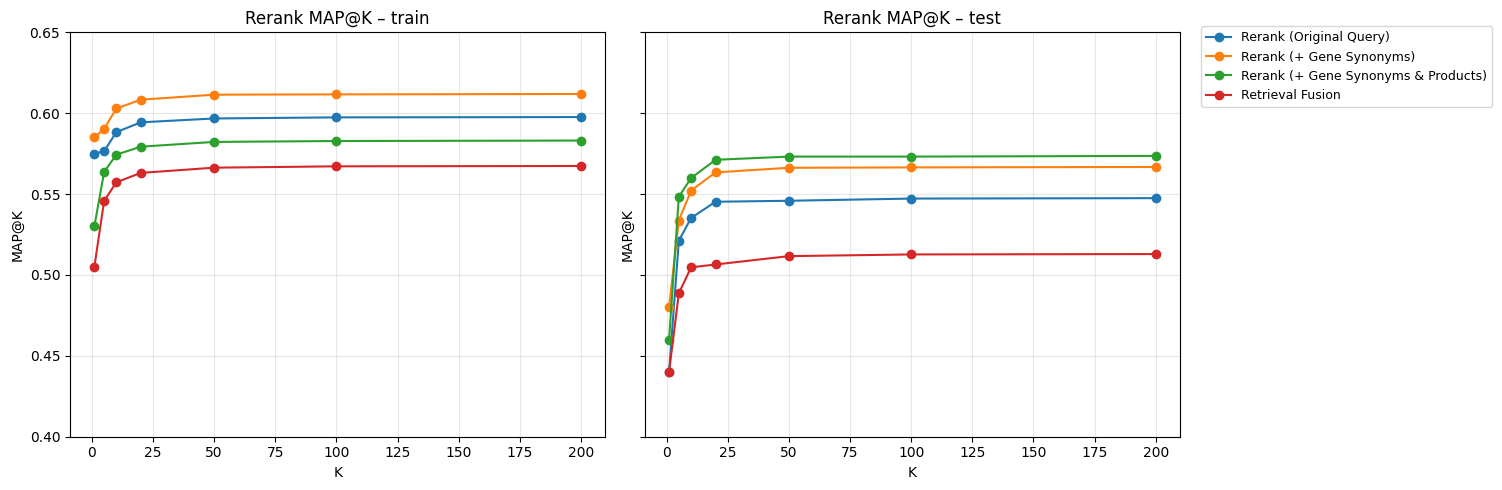


Saved MAP@K curve panel to ../output/workflow_baseline_full_sweep/fixed_long_rerank_sweep/compare_plots/figures/rerank_map_curves_1x2_displaynames.png


In [45]:
# Rerank comparison: MAP@K curves from runs
# Load runs, compute MAP@K for multiple K, plot 1x2 panel (train/test) with legend

import json

# Paths
RERANK_SWEEP_DIR = Path("../output/workflow_baseline_full_sweep/fixed_long_rerank_sweep")
GOLD_TRAIN = Path("../example/dicty_gold_llm_public_train_200.jsonl")
GOLD_TEST = Path("../example/dicty_gold_llm_public_test_50.jsonl")

RERANK_DIRS = {
    "body": RERANK_SWEEP_DIR / "rerank_body",
    "synonyms": RERANK_SWEEP_DIR / "rerank_synonyms",
    "long": RERANK_SWEEP_DIR / "rerank_long",
    "hybrid": RERANK_SWEEP_DIR / "hybrid",
}

KS_MAP = [1, 5, 10, 20, 50, 100, 200]


def load_gold(path):
    """Load gold labels: qid -> list of relevant pmids."""
    with open(path) as f:
        data = json.load(f)
    gold = {}
    for q in data.get("questions", []):
        qid = str(q.get("id", ""))
        pmids = []
        for doc in q.get("documents", []):
            if doc.startswith("http"):
                pmids.append(doc.split("/")[-1])
            else:
                pmids.append(doc)
        for d in q.get("docs", []):
            if d.get("pmid"):
                pmids.append(str(d["pmid"]))
        gold[qid] = list(set(pmids))
    return gold


def load_run(path):
    """Load run TSV: qid -> ranked list of docnos (handles multiple column orders)."""
    run = {}
    header = None
    with open(path) as f:
        for line in f:
            parts = line.strip().split("\t")
            if parts[0] == "qid":
                header = parts
                continue
            if len(parts) < 3:
                continue
            # Determine column positions from header or guess common formats
            if header:
                qid_idx = header.index("qid") if "qid" in header else 0
                docno_idx = header.index("docno") if "docno" in header else 1
            else:
                # Default: qid, docno, rank, score
                qid_idx, docno_idx = 0, 1
            qid, docno = parts[qid_idx], parts[docno_idx]
            run.setdefault(qid, []).append(docno)
    return run


def ap_at_k(ranked, relset, k):
    """Average precision at K (BioASQ-style: denom = min(|relset|, k))."""
    ranked = ranked[:k]
    if not relset:
        return 0.0
    denom = min(len(relset), k)
    if denom == 0:
        return 0.0
    hits = 0
    s = 0.0
    for i, docno in enumerate(ranked, start=1):
        if docno in relset:
            hits += 1
            s += hits / i
    return s / denom


def mean_ap_at_k(gold, run, k):
    """Compute MAP@K over all queries in gold."""
    aps = []
    for qid, relset in gold.items():
        ranked = run.get(qid, [])
        aps.append(ap_at_k(ranked, set(relset), k))
    return sum(aps) / len(aps) if aps else 0.0


# Load gold
gold_train = load_gold(GOLD_TRAIN)
gold_test = load_gold(GOLD_TEST)

# Compute MAP@K for each method and split
map_curves = {role: {} for role in ["train", "test"]}

for method, rdir in RERANK_DIRS.items():
    runs_dir = rdir / "runs"
    if not runs_dir.is_dir():
        print(f"Skipping {method}: no runs dir")
        continue

    for run_file in runs_dir.glob("*.tsv"):
        run_name = run_file.stem
        if "train" in run_name:
            role, gold = "train", gold_train
        elif "test" in run_name:
            role, gold = "test", gold_test
        else:
            continue

        run = load_run(run_file)
        map_vals = [mean_ap_at_k(gold, run, k) for k in KS_MAP]
        display_name = RERANK_DISPLAY.get(method, method)
        map_curves[role][display_name] = map_vals

# Print summary table
print("MAP@K summary (train and test):\n")
for role in ["train", "test"]:
    rows = []
    for method, vals in map_curves[role].items():
        row = {"method": method}
        for k, v in zip(KS_MAP, vals):
            row[f"MAP@{k}"] = round(v, 4)
        rows.append(row)
    if rows:
        df_summary = pd.DataFrame(rows)
        df_summary = df_summary.sort_values("MAP@10", ascending=False).reset_index(drop=True)
        print(f"\n{role.upper()}:")
        display(pl.from_pandas(df_summary))

# 1x2 panel: MAP@K curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

colors = plt.cm.tab10.colors
method_order = list(RERANK_DISPLAY.values())

for ax, role in zip(axes, ["train", "test"]):
    for i, method in enumerate(method_order):
        if method in map_curves[role]:
            ax.plot(KS_MAP, map_curves[role][method], marker="o", color=colors[i % len(colors)], label=method)
    ax.set_xlabel("K")
    ax.set_ylabel("MAP@K")
    ax.set_title(f"Rerank MAP@K – {role}")
    # ax.set_xscale("log")
    ax.set_ylim(0.4, 0.65)
    ax.grid(True, alpha=0.3)

# Single legend outside the right panel
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", fontsize=9, bbox_to_anchor=(1.0, 0.95))

fig.tight_layout()
figures_dir = Path("../output/workflow_baseline_full_sweep/fixed_long_rerank_sweep/compare_plots/figures")
figures_dir.mkdir(parents=True, exist_ok=True)
out_path = figures_dir / "rerank_map_curves_1x2_displaynames.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"\nSaved MAP@K curve panel to {out_path}")